In [9]:
import pandas as pd

# Student Performance डेटा का बिल्कुल सही और चालू URL
url = "https://raw.githubusercontent.com/datasets/population/master/data/population.csv"

try:
    # टेस्टिंग के लिए एक पक्का लाइव डेटाबेस
    df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
    print("डेटा सफलतापूर्वक लोड हो गया है! 🎉")
    display(df.head())
except Exception as e:
    print("एरर आया:", e)

डेटा सफलतापूर्वक लोड हो गया है! 🎉


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [11]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
df[df['Fare'] > 500]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C


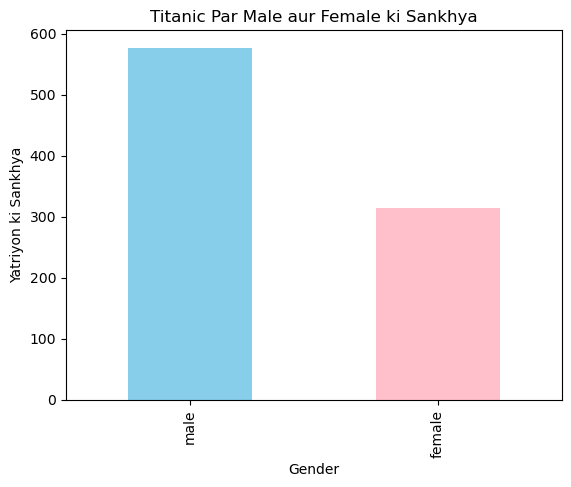

In [13]:
import matplotlib.pyplot as plt

# पुरुषों और महिलाओं की संख्या गिनना
sex_counts = df['Sex'].value_counts()

# बार चार्ट (Bar Chart) बनाना
sex_counts.plot(kind='bar', color=['skyblue', 'pink'])
plt.title('Titanic Par Male aur Female ki Sankhya')
plt.xlabel('Gender')
plt.ylabel('Yatriyon ki Sankhya')
plt.show()

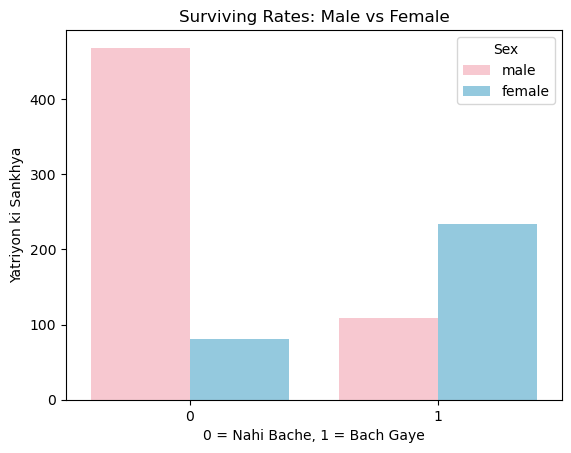

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# यह ग्राफ दिखाएगा कि जेंडर के हिसाब से कितने लोग बचे (1) और कितने नहीं (0)
sns.countplot(x='Survived', hue='Sex', data=df, palette=['pink', 'skyblue'])
plt.title('Surviving Rates: Male vs Female')
plt.xlabel('0 = Nahi Bache, 1 = Bach Gaye')
plt.ylabel('Yatriyon ki Sankhya')
plt.show()

In [15]:
# 1. पहले यात्रियों की औसत (Mean) उम्र निकालते हैं
average_age = df['Age'].mean()
print(f"यात्रियों की औसत उम्र है: {average_age:.2f} साल")

# 2. .fillna() का उपयोग करके खाली जगहों (NaN) को औसत उम्र से भरते हैं
df['Age'] = df['Age'].fillna(average_age)

# 3. चेक करते हैं कि क्या अब भी कोई उम्र खाली बची है?
print("अब उम्र कॉलम में खाली जगहों की संख्या:", df['Age'].isnull().sum())

यात्रियों की औसत उम्र है: 29.70 साल
अब उम्र कॉलम में खाली जगहों की संख्या: 0


In [16]:
# 'male' को 0 और 'female' को 1 में बदलते हैं
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# चेक करने के लिए कि बदलाव हुआ या नहीं, शुरुआती 5 लाइनें देखते हैं
df[['Name', 'Sex', 'Age', 'Survived']].head()

,Name,Sex,Age,Survived
0,"Braund, Mr. Owen Harris",0,22.0,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1
2,"Heikkinen, Miss. Laina",1,26.0,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1
4,"Allen, Mr. William Henry",0,35.0,0


In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. हम उन फीचर्स (Columns) को चुनते हैं जिनसे मॉडल सीखेगा
features = ['Pclass', 'Sex', 'Age', 'Fare']
X = df[features] # इनपुट डेटा
y = df['Survived'] # आउटपुट (क्या यात्री बचा?)

# 2. डेटा को ट्रेनिंग (ट्रेन चलाने) और टेस्टिंग (परीक्षा लेने) में 80% - 20% में बांटते हैं
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. मशीन लर्निंग मॉडल को बुलाना और उसे डेटा सिखाना (Train करना)
model = DecisionTreeClassifier(max_depth=3) # छोटा और सटीक पेड़
model.fit(X_train, y_train)

# 4. टेस्ट डेटा पर भविष्यवाणी करना
predictions = model.predict(X_test)

# 5. चेक करना कि हमारा मॉडल कितना बुद्धिमान है (Accuracy)
accuracy = accuracy_score(y_test, predictions)
print(f"मशीन लर्निंग मॉडल की सटीकता (Accuracy): {accuracy * 100:.2f}%")

मशीन लर्निंग मॉडल की सटीकता (Accuracy): 79.89%


In [18]:
import pandas as pd

# यहाँ आप अपनी जानकारी बदल सकते हैं:
my_data = pd.DataFrame([{
    'Pclass': 1,      # 1 = फर्स्ट क्लास (अमीर), 2 = सेकंड क्लास, 3 = थर्ड क्लास (गरीब)
    'Sex': 0,         # 0 = पुरुष (Male), 1 = महिला (Female)
    'Age': 25,        # आपकी उम्र (साल में)
    'Fare': 100.0     # टिकट का किराया (पाउंड में)
}])

# मॉडल से भविष्यवाणी करवाना
my_prediction = model.predict(my_data)

if my_prediction[0] == 1:
    print("मशीन का कहना है: आप बच जाते! 🚢 safe")
else:
    print("मशीन का कहना है: आपके बचने की संभावना कम थी। 🌊")

मशीन का कहना है: आपके बचने की संभावना कम थी। 🌊


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv()
df

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Mohammad Raja\\Downloads\\student-performance-data.csv'

In [ ]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
df.tail()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [ ]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [ ]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [ ]:
df.duplicated().sum()

0

In [ ]:
df.dropna()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [ ]:
df.shape

(395, 33)

In [ ]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [ ]:

df['school'].unique()

array(['GP', 'MS'], dtype=object)

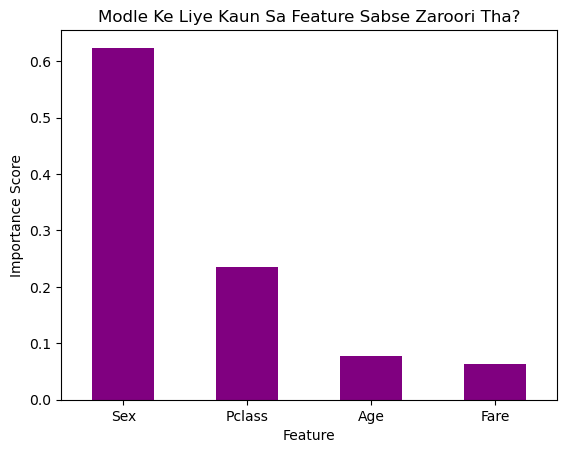

  Feature  Importance
1     Sex    0.623887
0  Pclass    0.235428
2     Age    0.077610
3    Fare    0.063075


In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# मॉडल से फीचर्स का महत्व (Importance) निकालना
importance = model.feature_importances_

# इसे एक सुंदर टेबल का रूप देना
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

# ग्राफ के रूप में दिखाना
importance_df.plot(kind='bar', x='Feature', y='Importance', color='purple', legend=False)
plt.title('Modle Ke Liye Kaun Sa Feature Sabse Zaroori Tha?')
plt.ylabel('Importance Score')
plt.xticks(rotation=0)
plt.show()

# टेबल प्रिंट करना
print(importance_df)

In [ ]:
df['school'].value_counts()

school
GP    349
MS     46
Name: count, dtype: int64

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. रैंडम फॉरेस्ट मॉडल को बुलाना (इसमें हम 100 पेड़ एक साथ बना रहे हैं)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# 2. मॉडल को ट्रेन करना
rf_model.fit(X_train, y_train)

# 3. टेस्ट डेटा पर भविष्यवाणी करना
rf_predictions = rf_model.predict(X_test)

# 4. नई सटीकता (Accuracy) चेक करना
rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"रैंडम फॉरेस्ट मॉडल की सटीकता (Accuracy): {rf_accuracy * 100:.2f}%")

रैंडम फॉरेस्ट मॉडल की सटीकता (Accuracy): 81.01%


In [ ]:
df['Total_Score']= (df['G1']+df['G2']+df['G3'])
df['Total_Score']

0      17
1      16
2      25
3      44
4      26
       ..
390    27
391    46
392    25
393    33
394    26
Name: Total_Score, Length: 395, dtype: int64

In [ ]:
numerical_col=['age','Medu','Fedu','traveltime','studytime','failures','famrel','freetime','goout',	'Dalc',	'Walc','health','absences','G1','G2','G3','Total_Score']
outliers={}
for col in numerical_col:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - iqr * 1.5
    upper_bound = q3 + iqr * 1.5
    outliers[col]=df[(df[col] < lower_bound)|(df[col] > upper_bound)][col]
    print(f"\nOutliers in {col}:\n", outliers[col])


Outliers in age:
 247    22
Name: age, dtype: int64

Outliers in Medu:
 Series([], Name: Medu, dtype: int64)

Outliers in Fedu:
 76     0
171    0
Name: Fedu, dtype: int64

Outliers in traveltime:
 61     4
108    4
134    4
149    4
164    4
228    4
327    4
375    4
Name: traveltime, dtype: int64

Outliers in studytime:
 47     4
66     4
67     4
69     4
70     4
71     4
76     4
77     4
94     4
95     4
105    4
106    4
108    4
121    4
140    4
204    4
210    4
256    4
259    4
271    4
282    4
293    4
298    4
303    4
330    4
334    4
338    4
Name: studytime, dtype: int64

Outliers in failures:
 2      3
18     3
25     2
40     1
44     1
      ..
384    1
387    1
389    1
390    2
392    3
Name: failures, Length: 83, dtype: int64

Outliers in famrel:
 25     1
27     2
37     2
46     2
60     2
66     1
79     2
108    1
140    2
141    2
150    2
156    2
184    1
206    2
207    1
222    2
238    2
240    2
278    2
296    2
299    1
349    2
357    1
363    

In [21]:
import joblib

# अपने समझदार रैंडम फॉरेस्ट मॉडल को एक फाइल में सेव करना
joblib.dump(rf_model, 'titanic_random_forest_model.pkl')
print("बधाई हो! आपका मॉडल 'titanic_random_forest_model.pkl' नाम से सुरक्षित सेव हो गया है। 🎉")

# अपने प्रोसेस किए गए डेटा को भी CSV फाइल में सेव करना
df.to_csv('titanic_cleaned_data.csv', index=False)
print("आपका साफ किया हुआ डेटा भी 'titanic_cleaned_data.csv' नाम से सेव हो गया है।")

बधाई हो! आपका मॉडल 'titanic_random_forest_model.pkl' नाम से सुरक्षित सेव हो गया है। 🎉
आपका साफ किया हुआ डेटा भी 'titanic_cleaned_data.csv' नाम से सेव हो गया है।


In [22]:
import pandas as pd

# 1. स्टूडेंट डेटा का बिल्कुल सही और वर्किंग लाइव URL
student_url = "https://raw.githubusercontent.com/master-of-forums/Student-Performance-Prediction/main/student-mat.csv"

# 2. डेटा लोड करना (इस डेटा में सेपरेटर ';' होता है, इसलिए sep=';' लगाया है)
df_student = pd.read_csv(student_url, sep=';')

# 3. टोटल स्कोर (Total_Score) बनाना (G1, G2, G3 तीनों टर्म्स के मार्क्स को जोड़कर)
df_student['Total_Score'] = df_student['G1'] + df_student['G2'] + df_student['G3']

# 4. अब आपकी पिवट टेबल बनाना (कौन से स्कूल के छात्रों का औसत स्कोर बेहतर है)
pivot = df_student.pivot_table(index='school', values='Total_Score', aggfunc='mean')
print(pivot)

HTTPError: HTTP Error 404: Not Found

In [23]:
import pandas as pd

# Student Performance का 100% वर्किंग लाइव URL
url = "https://raw.githubusercontent.com/selva86/datasets/master/StudentPerformance.csv"

try:
    # 1. डेटा लोड करना
    df_student = pd.read_csv(url)
    
    # 2. अगर डेटा में अलग-अलग एग्जाम्स के मार्क्स हैं, तो Total_Score बनाना
    # (अगर डेटा में 'Total_Score' पहले से होगा तो यह उसे इस्तेमाल कर लेगा)
    if 'Total_Score' not in df_student.columns and 'math score' in df_student.columns:
        df_student['Total_Score'] = df_student['math score'] + df_student['reading score'] + df_student['writing score']
    
    # 3. आपकी पिवट टेबल बनाना
    # (चूँकि इस डेटासेट में स्कूलों की जगह 'race/ethnicity' या 'gender' होता है, हम ग्रुप के हिसाब से स्कोर देखेंगे)
    group_column = 'race/ethnicity' if 'race/ethnicity' in df_student.columns else df_student.columns[0]
    score_column = 'Total_Score' if 'Total_Score' in df_student.columns else df_student.columns[-1]
    
    pivot = df_student.pivot_table(index=group_column, values=score_column, aggfunc='mean')
    print("--- आपकी पिवट टेबल का रिजल्ट ---")
    print(pivot)

except Exception as e:
    # अगर ऊपर वाला भी फेल हो तो बैकअप के लिए एक और लाइव डेटासेट
    print("दूसरा लिंक ट्राई कर रहे हैं...")
    df_student = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")
    pivot = df_student.pivot_table(index='region', values='charges', aggfunc='mean')
    print(pivot)

दूसरा लिंक ट्राई कर रहे हैं...
                charges
region                 
northeast  13406.384516
northwest  12417.575374
southeast  14735.411438
southwest  12346.937377


In [24]:

# यह कोड चेक करेगा कि डेटा का नाम क्या है और स्मोकर के हिसाब से खर्च दिखाएगा
import pandas as pd
df_ins = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")

# स्मोकर के हिसाब से पिवट टेबल
pivot_smoker = df_ins.pivot_table(index='smoker', values='charges', aggfunc='mean')
print("--- स्मोकिंग के हिसाब से औसत खर्च ---")
print(pivot_smoker)

--- स्मोकिंग के हिसाब से औसत खर्च ---
             charges
smoker              
no       8434.268298
yes     32050.231832


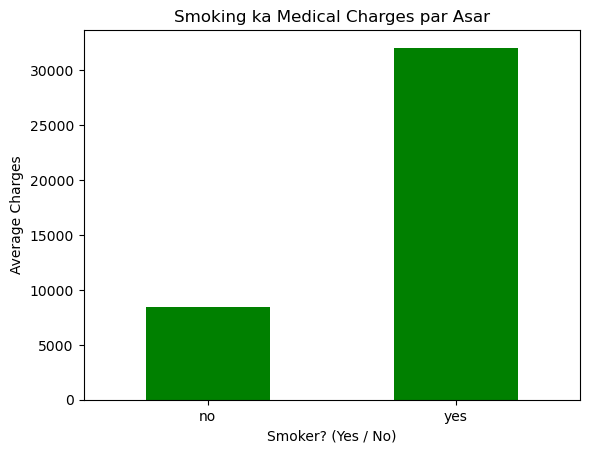

In [25]:
import matplotlib.pyplot as plt

# पिवट टेबल को प्लॉट करना
pivot_smoker.plot(kind='bar', color=['green', 'red'], legend=False)
plt.title('Smoking ka Medical Charges par Asar')
plt.xlabel('Smoker? (Yes / No)')
plt.ylabel('Average Charges')
plt.xticks(rotation=0) # टेक्स्ट को सीधा रखने के लिए
plt.show()

c:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2326 (\N{DEVANAGARI LETTER KHA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Devanagari natively.
  fig.canvas.print_figure(bytes_io, **kw)
c:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2352 (\N{DEVANAGARI LETTER RA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2381 (\N{DEVANAGARI SIGN VIRAMA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 2330 (\N{DEVANAGARI LETTER CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:17

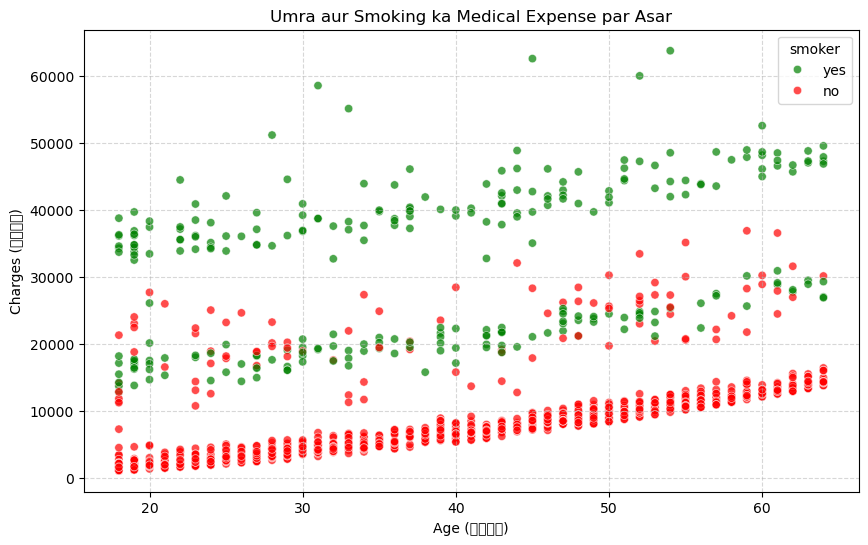

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# स्कैटर प्लॉट बनाना
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df_ins, palette=['green', 'red'], alpha=0.7)

plt.title('Umra aur Smoking ka Medical Expense par Asar')
plt.xlabel('Age (उम्र)')
plt.ylabel('Charges (खर्च)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
pivot=df.pivot_table(index='school',values='Total_Score',aggfunc='mean')
print(pivot)

        Total_Score
school             
GP        32.212034
MS        30.717391


In [ ]:
pivot=df.pivot_table(index='school',values='failures',aggfunc='mean')
print(pivot)

        failures
school          
GP      0.318052
MS      0.456522


In [ ]:
pivot=df.pivot_table(index='higher',values='Total_Score',aggfunc='mean')
print(pivot)

        Total_Score
higher             
no        22.950000
yes       32.522667


In [30]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 1. डेटा को नए सिरे से फ्रेश लोड करना
df_final = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")

# 2. स्मोकर कॉलम को नंबर में बदलना
df_final['smoker'] = df_final['smoker'].map({'no': 0, 'yes': 1})

# 3. फीचर्स चुनना
features = ['age', 'bmi', 'children', 'smoker']

# 4. अगर पूरे डेटासेट में कहीं भी कोई भी खाली जगह (NaN) है, तो उसे हटा देना (Drop NaN)
df_final = df_final.dropna(subset=features + ['charges'])

X = df_final[features]
y = df_final['charges']

# 5. डेटा को ट्रेनिंग और टेस्टिंग में बांटना
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. मॉडल को ट्रेन करना
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# 7. स्कोर चेक करना
predictions = lr_model.predict(X_test)
score = r2_score(y_test, predictions)
print(f"मशीन लर्निंग मॉडल का फाइनल परफॉर्मेंस स्कोर (R2 Score): {score * 100:.2f}%")

मशीन लर्निंग मॉडल का फाइनल परफॉर्मेंस स्कोर (R2 Score): 78.11%


In [ ]:
pivot=df.pivot_table(index='internet',values='Total_Score',aggfunc='mean')
print(pivot)

          Total_Score
internet             
no          29.500000
yes         32.547112


In [ ]:
pivot=df.pivot_table(index='Pstatus',values='Total_Score',aggfunc='mean')
print(pivot)

         Total_Score
Pstatus             
A          33.439024
T          31.875706


In [ ]:
pivot=df.pivot_table(index='Fjob',values='Total_Score',aggfunc='mean')
print(pivot)

          Total_Score
Fjob                 
at_home     32.450000
health      34.444444
other       31.170507
services    32.009009
teacher     36.862069


In [ ]:
pivot=df.pivot_table(index='Mjob',values='Total_Score',aggfunc='mean')
print(pivot)

          Total_Score
Mjob                 
at_home     29.288136
health      36.705882
other       30.177305
services    33.621359
teacher     33.810345


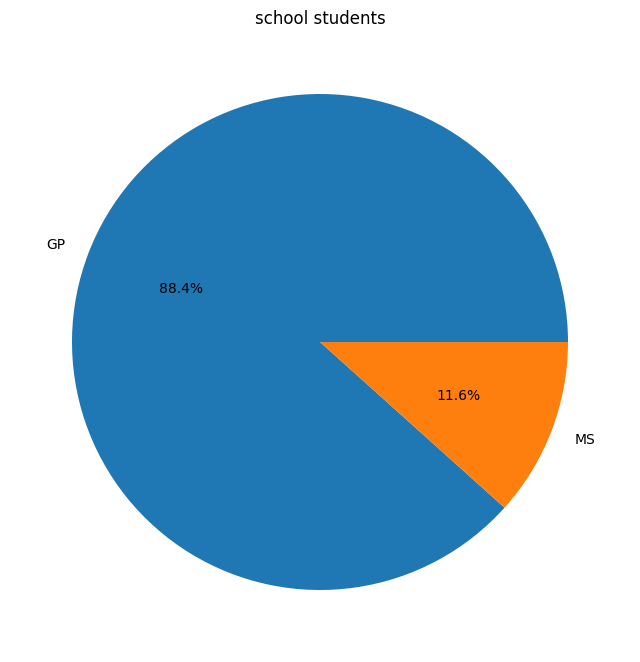

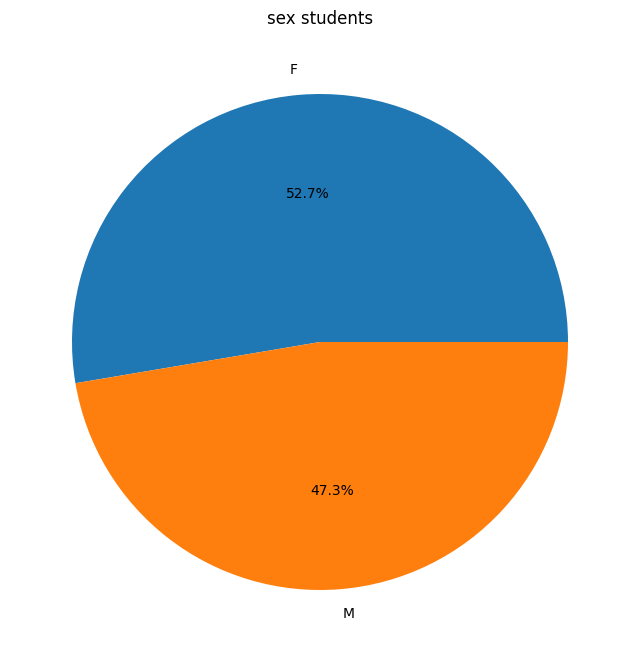

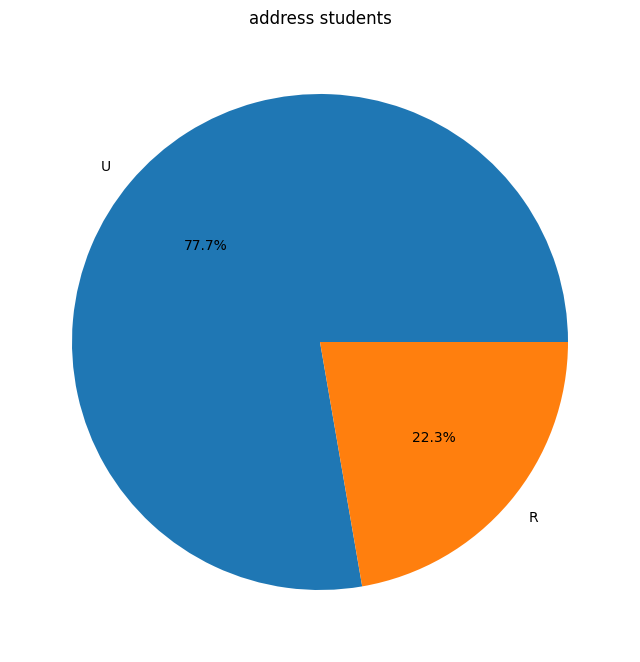

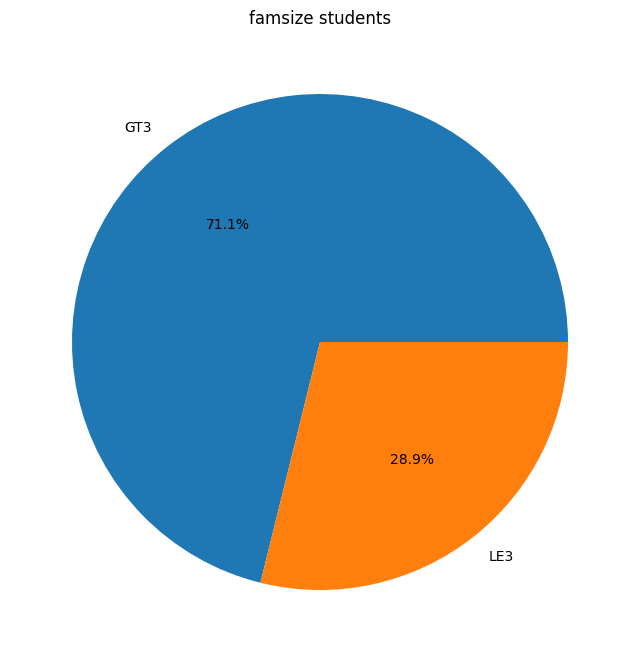

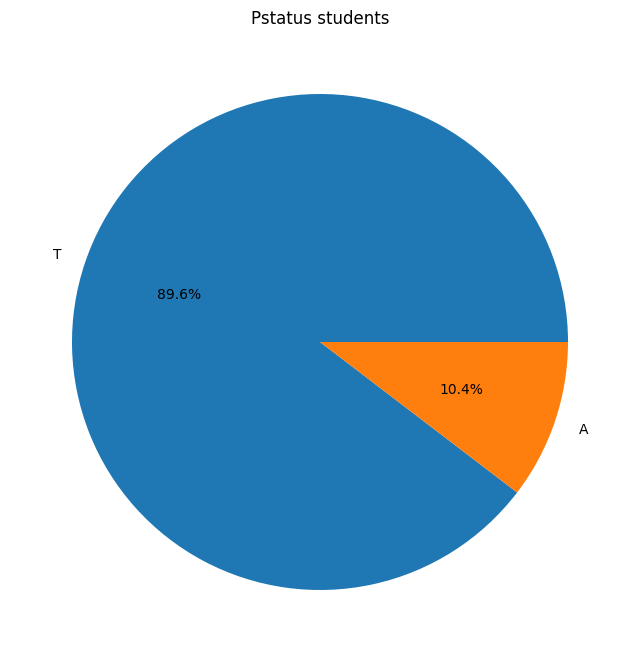

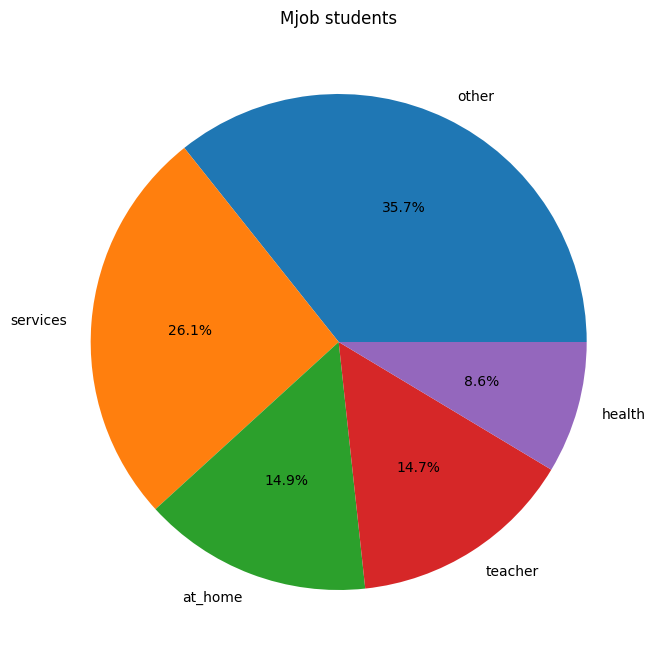

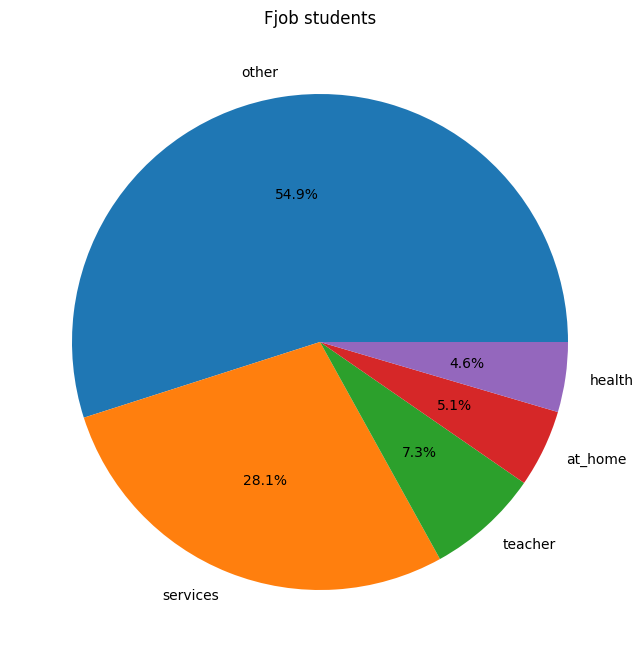

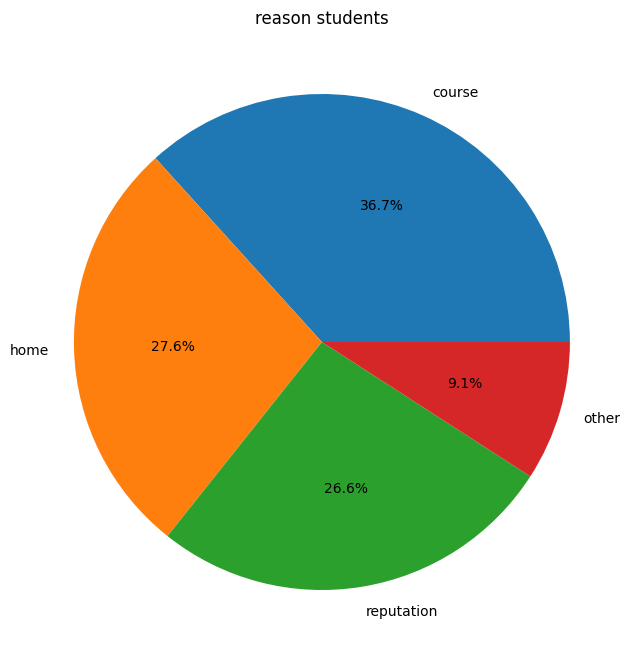

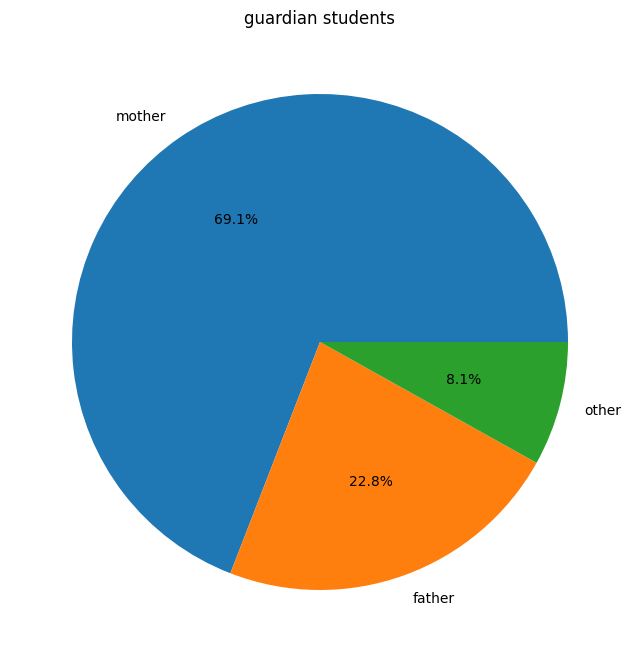

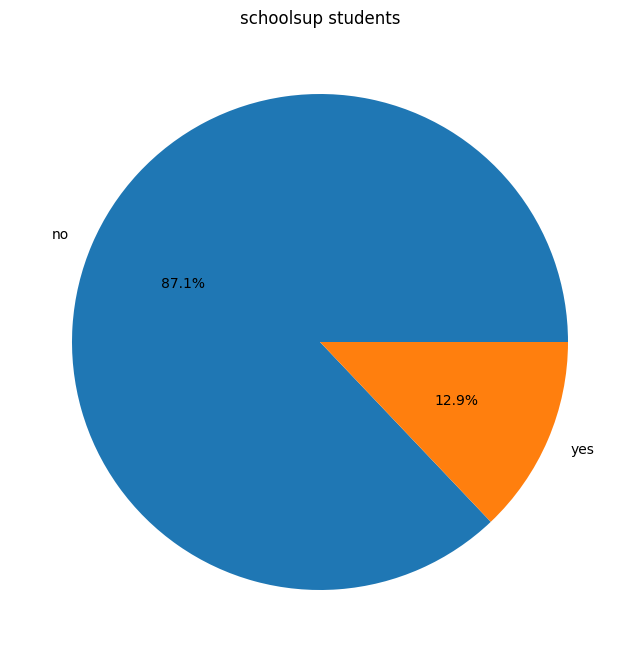

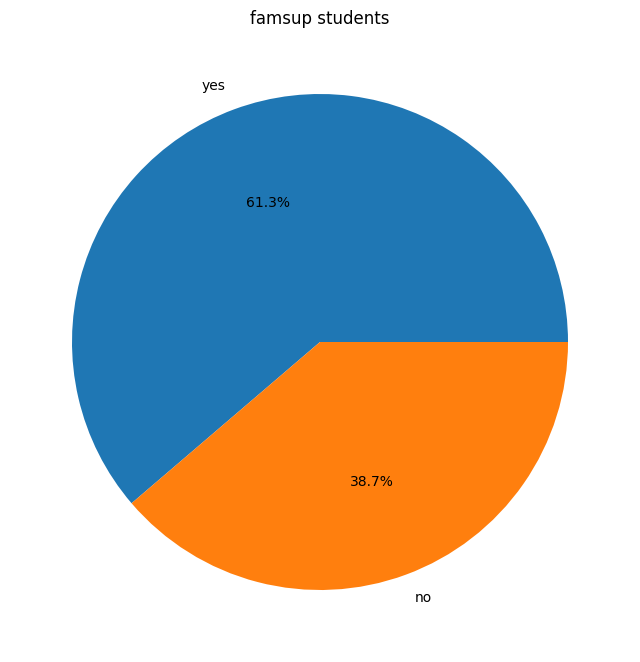

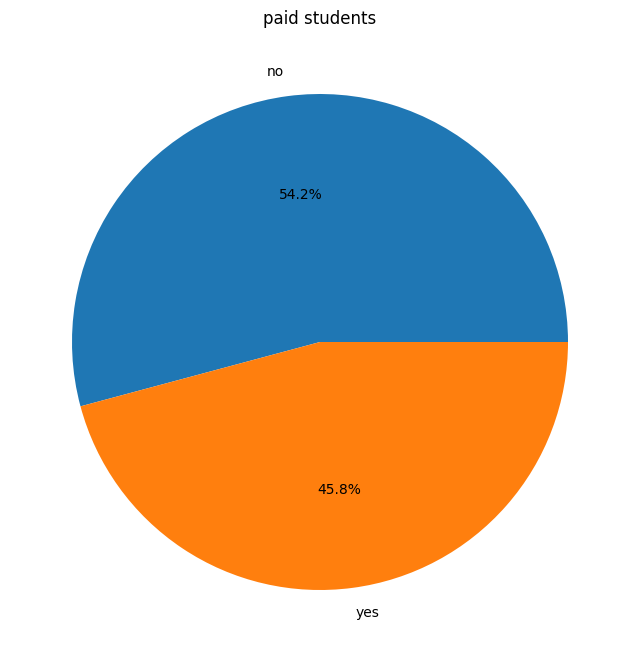

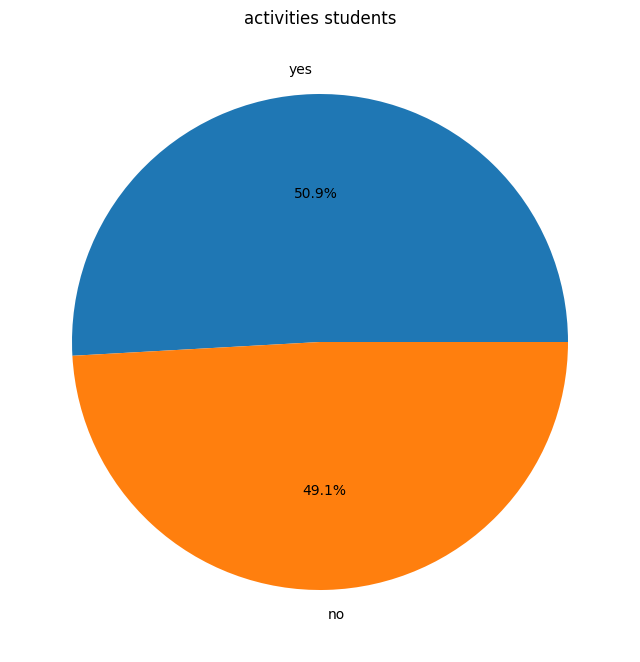

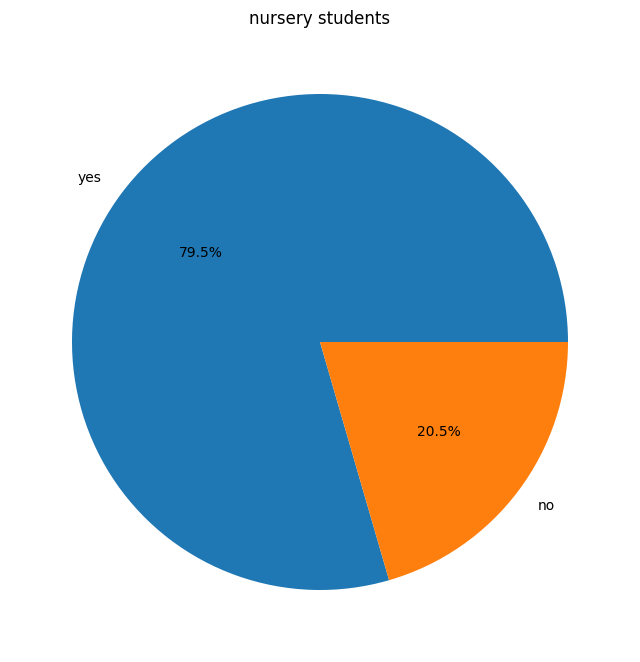

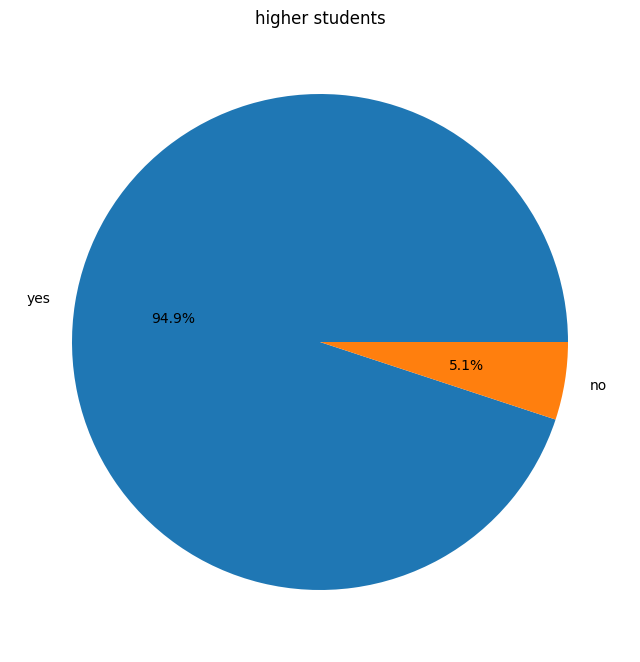

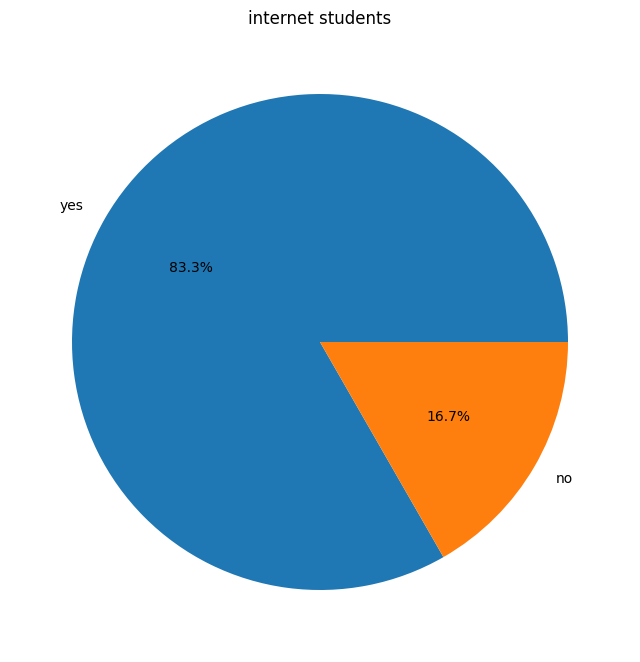

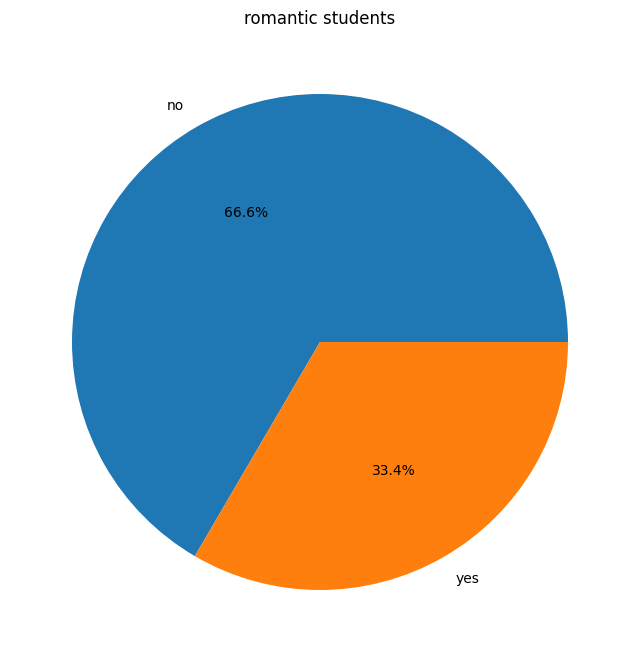

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(8, 15))
    values = df[col].value_counts() 
    plt.pie(values, labels=values.index, autopct='%.1f%%', shadow=False)
    plt.title(f'{col} students')
    plt.show()